In [40]:
import pandas as pd
import os
os.chdir("C:/Users/yair_/OneDrive/Desktop/Ciencia de Datos/Módulo 57 - Modelos ARIMA(p,d,q)")

df = pd.read_csv("TempNY.csv")
df

,Year,Average,Unnamed: 2
0,1870,53.60,NaN
1,1871,51.13,NaN
2,1872,50.98,NaN
3,1873,50.98,NaN
4,1874,51.34,NaN
...,...,...,...
146,2016,57.18,NaN
147,2017,56.22,NaN
148,2018,55.88,NaN
149,2019,55.62,NaN


In [41]:
df = df.drop(columns = ["Unnamed: 2"])
df.index = df["Year"]
df = df.drop("Year", axis = 1)
df

,Average
Year,
1870,53.60
1871,51.13
1872,50.98
1873,50.98
1874,51.34
...,...
2016,57.18
2017,56.22
2018,55.88


In [43]:
# Se establecen los conjuntos para datos de entrenamiento y prueba
len_train = int(len(df) * 0.9)
len_test = len(df) - len_train
train = df[0:len_train]
test = df[len_train:]

<Axes: xlabel='Year'>

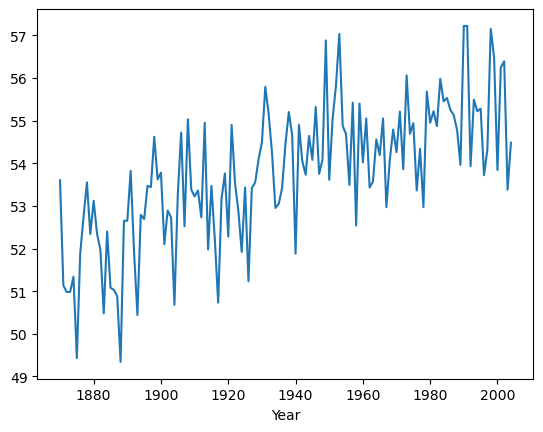

In [46]:
train["Average"].plot()

In [47]:
#Prueba de Dickey-Fuller a datos de entrenamiento
from statsmodels.tsa.stattools import adfuller
result = adfuller(train["Average"])
print("El valor p de la prueba de Dickey-Fuller es: ", result[1])

El valor p de la prueba de Dickey-Fuller es:  0.42201206191180785


In [48]:
# Se aplican primeras diferencias para buscar convertir esta serie en una serie estacionaria
train["temp_change"] = train["Average"].diff()
train = train.dropna()

<Axes: xlabel='Year'>

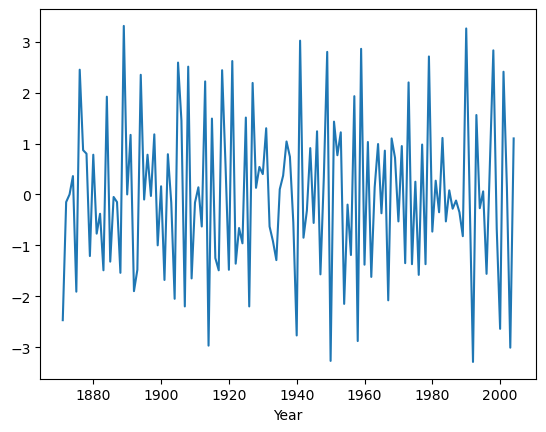

In [49]:
train["temp_change"].plot()

In [50]:
# Aplicación de la prueba Dickey-Fuller sobre las diferencias calculadas en base de datos de entrenamiento
result2 = adfuller(train["temp_change"])
print("El valor p de la prueba Dickey-Fuller es: ", result2[1])

El valor p de la prueba Dickey-Fuller es:  1.5713108896118464e-13


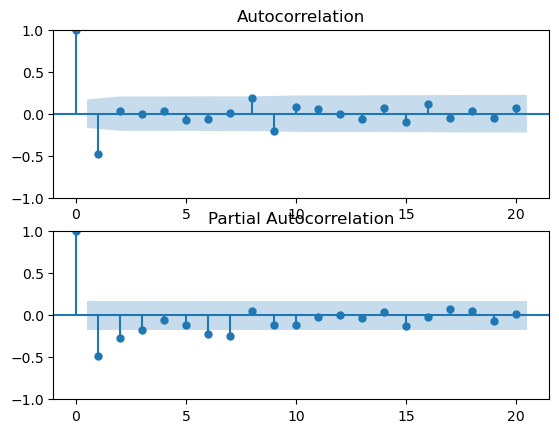

In [52]:
# Analizando la autocorrelación de los datos para definir los parámetros óptimos del modelo
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2,1)

#Graficación de la función de autocorrelación ACF
plot_acf(train["temp_change"], lags = 20, ax = axes[0], alpha = 0.05)

#Graficación de la función de autocorrelación parcial PACF
plot_pacf(train["temp_change"], lags = 20, ax = axes[1], alpha = 0.05)

plt.show()

Con ayuda de la gráfica, se observa que el valor inmediato anterior en la serie, es el que mejor predice el valor actual. De igual forma, se comprueba esta conclusión realizando pruebas con diferentes valores de p en el modelo AR(p)

In [53]:
# Importación del módulo para estimar un modelo ARIMA (primera combinación)
from statsmodels.tsa.arima.model import ARIMA

#Ajustar los datos a un modelo AR(1) e imprimir su AIC
mod_ar1 = ARIMA(train["temp_change"], order = (1,0,0))
res_ar1 = mod_ar1.fit()
print("El AIC para AR(1) es: ", res_ar1.aic)

El AIC para AR(1) es:  464.2789529854747


In [55]:
#Ajustar los datos a un modelo AR(2) e imprimir su AIC (segunda combinación)
mod_ar2 = ARIMA(train["temp_change"], order = (2,0,0))
res_ar2 = mod_ar2.fit()
print("El AIC para AR(1) es: ", res_ar2.aic)

El AIC para AR(1) es:  455.4886439186555


In [56]:
#Ajustar los datos a un modelo ARMA(1,1) e imprimir su AIC (tercera combinación)
mod_arma11 = ARIMA(train["temp_change"], order = (1,0,1))
res_arma11 = mod_arma11.fit()
print("El AIC para AR(1) es: ", res_arma11.aic)

El AIC para AR(1) es:  428.92693283531935


In [57]:
#Ajustar los datos a un modelo ARMA(1,1) e imprimir su AIC (cuarta combinación)
mod_arma11 = ARIMA(train["temp_change"], order = (2,0,1))
res_arma11 = mod_arma11.fit()
print("El AIC para AR(1) es: ", res_arma11.aic)

El AIC para AR(1) es:  430.2016999801665


In [58]:
#Ajustar los datos a un modelo ARMA(1,1) e imprimir su AIC (quinta combinación)
mod_arma11 = ARIMA(train["temp_change"], order = (2,0,2))
res_arma11 = mod_arma11.fit()
print("El AIC para AR(1) es: ", res_arma11.aic)

El AIC para AR(1) es:  430.2840584606017


In [59]:
#Ajustar los datos a un modelo ARMA(1,1) e imprimir su AIC (sexta combinación)
mod_arma11 = ARIMA(train["temp_change"], order = (2,0,3))
res_arma11 = mod_arma11.fit()
print("El AIC para AR(1) es: ", res_arma11.aic)

El AIC para AR(1) es:  428.46354657435023


### Conclusión: La serie de tiempo original de temperaturas se modela bien con ARIMA(1,1,1), ya que es el modelo que arroja mejor estadistico de Akaike

In [60]:
df = pd.read_csv("TempNY.csv")
df = df.drop(columns = ["Unnamed: 2"])
df.index = df["Year"]
df = df.drop("Year", axis = 1)
df

,Average
Year,
1870,53.60
1871,51.13
1872,50.98
1873,50.98
1874,51.34
...,...
2016,57.18
2017,56.22
2018,55.88


In [64]:
#Importación del módulo ARIMA de statsmodels
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict

#Pronóstico de temperaturas usando un modelo ARIMA(1,1,1)
mod = ARIMA(df["Average"], order = (1,1,1))
res = mod.fit()

print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                Average   No. Observations:                  151
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -238.826
Date:                Tue, 07 Apr 2026   AIC                            483.652
Time:                        16:20:28   BIC                            492.683
Sample:                             0   HQIC                           487.321
                                - 151                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0646      0.109      0.590      0.555      -0.150       0.279
ma.L1         -0.8669      0.057    -15.261      0.000      -0.978      -0.756
sigma2         1.4020      0.199      7.043      0.0

In [67]:
# Se realizan las predicciones de la base de prueba
predicciones = res.forecast(len(test))

test = pd.DataFrame(test)
predicciones = pd.DataFrame(predicciones)
test = test.reset_index()
predicciones = predicciones.reset_index()

In [72]:
import numpy as np

acumulador1 = 0
acumulador2 = 0

for contador in range(0,len_test):
    acumulador1 = acumulador1 + (test.iloc[contador,1] - predicciones.iloc[contador,1]) ** 2
    acumulador2 = acumulador2 + np.abs((test.iloc[contador,1] - predicciones.iloc[contador,1]) / test.iloc[contador,1])

mse = acumulador1 / len_test
rmse = np.round(np.sqrt(mse), 2)
mape = np.round((acumulador2 / len_test) * 100, 2)
print("RMSE = ", rmse, "MAPE = ", mape)

RMSE =  0.98 MAPE =  1.5


In [73]:
#Intervalos de confianza para las predicciones con alpha de 5%
conf = res.get_forecast(len_test).conf_int(alpha = 0.05)
conf

,lower Average,upper Average
151,53.829710,58.471183
152,53.711871,58.443137
153,53.683071,58.462516
154,53.659995,58.484984
155,53.637485,58.507455
156,53.615203,58.529735
157,53.593122,58.551815
158,53.571237,58.573700
159,53.549541,58.595396
160,53.528031,58.616906


In [83]:
#Para acomodar las fechas como index en todos los data frames y graficar
lista = test["Year"]
lista = pd.DataFrame(lista)
predicciones.drop(columns = ["index"], inplace = True)
frames = [lista, predicciones]
result = pd.concat(frames, axis = 1, join = "inner")
result.columns = ["Year", "Predicciones"]
result

,Year,Predicciones
0,2005,56.150446
1,2006,56.077504
2,2007,56.072794
3,2008,56.072490
4,2009,56.072470
5,2010,56.072469
6,2011,56.072469
7,2012,56.072469
8,2013,56.072469
9,2014,56.072469


In [85]:
conf = conf.reset_index()
conf.drop(columns = ["index"], inplace = True)
conf

,lower Average,upper Average
0,53.829710,58.471183
1,53.711871,58.443137
2,53.683071,58.462516
3,53.659995,58.484984
4,53.637485,58.507455
5,53.615203,58.529735
6,53.593122,58.551815
7,53.571237,58.573700
8,53.549541,58.595396
9,53.528031,58.616906


In [86]:
frames = [lista, conf]
intervalos = pd.concat(frames, axis = 1, join = "inner")
intervalos

,Year,lower Average,upper Average
0,2005,53.829710,58.471183
1,2006,53.711871,58.443137
2,2007,53.683071,58.462516
3,2008,53.659995,58.484984
4,2009,53.637485,58.507455
5,2010,53.615203,58.529735
6,2011,53.593122,58.551815
7,2012,53.571237,58.573700
8,2013,53.549541,58.595396
9,2014,53.528031,58.616906


In [87]:
test.index = test["Year"]
test.drop(columns = ["Year"], inplace = True)
result.index = result["Year"]
result.drop(columns = ["Year"], inplace = True)
intervalos.index = intervalos["Year"]
intervalos.drop(columns = ["Year"], inplace = True)

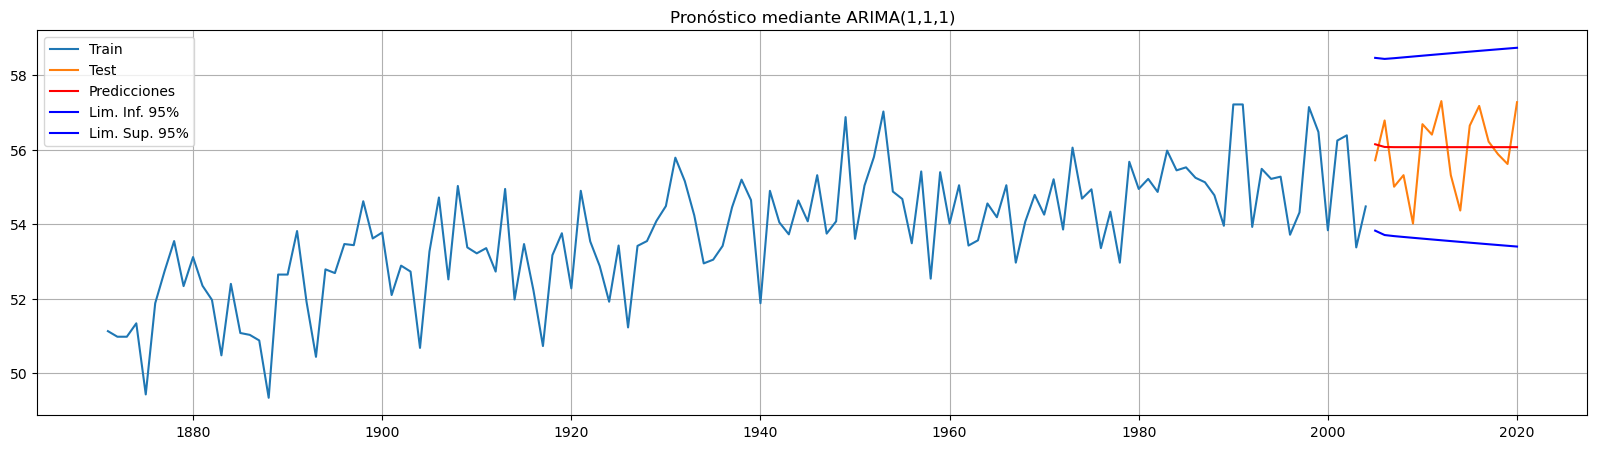

In [91]:
plt.figure(figsize = (20,5))
plt.grid()
plt.plot(train["Average"], label = "Train")
plt.plot(test, label = "Test")
plt.plot(result, label = "Predicciones", color = "red")
plt.plot(intervalos["lower Average"], label = "Lim. Inf. 95%", color = "blue")
plt.plot(intervalos["upper Average"], label = "Lim. Sup. 95%", color = "blue")
plt.legend(loc = "best")
plt.title("Pronóstico mediante ARIMA(1,1,1)")
plt.show()